In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

In [9]:
# termpicks = gpd.read_file('/Users/cjense/Desktop/phd/Terminus Tracing/Data/TermPicks/TermPicks_V2/TermPicks_V2.shp')
# zach_autoterm = gpd.read_file('/Users/cjense/Desktop/phd/Terminus Tracing/Data/AutoTerm/GID102.shp')
# nsidc = gpd.read_file('/Users/cjense/Desktop/phd/Terminus Tracing/Data/NSIDC Termini/glacier_termini_v01.0.shp')
# sofia_termini = gpd.read_file('/Users/cjense/Desktop/phd/Terminus Tracing/Data/Sofia ZI Termini/QGIS_GrIMPtraces_sofia.shp')
# jensen_termini = gpd.read_file('/Users/cjense/Desktop/phd/Data/Termini/Jensen_traces_ZI_2.shp')

jensen_termini = gpd.read_file('/Users/cjense/Desktop/phd/Data/Termini/Jensen_and_othertraces_ZI_2.shp')

# termpicks = gpd.read_file('/home/cjensen/phd/Data/TermPicks/TermPicks_V2/TermPicks_V2.shp')
# zach_autoterm = gpd.read_file('/home/cjensen/phd/Data/AutoTerm/GID102.shp')
# nsidc = gpd.read_file('/home/cjensen/phd/Data/NSIDC Termini/glacier_termini_v01.0.shp')
# sofia_termini = gpd.read_file('/home/cjensen/phd/Data/Sofia ZI Termini/QGIS_GrIMPtraces_sofia.shp')
# jensen_termini = gpd.read_file('/home/cjensen/phd/Data/Jensen Termini/Jensen_SupplementaryTraces_ZI_2.shp')

## NSIDC

All data are manually traced from GrIMP Sentinel-1 imagery.

/home/cjensen/miniconda3/envs/cjensetools/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/cjensen/miniconda3/envs/cjensetools/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,Image_ID,Image_Tile,SourceDate,Quality_Fl,Glacier_ID,geometry,Year,Month
312,SEN1_NSIDC_0723_V2_20150113_20150124,S1A_170_004267,2015-01-21,0,107,"LINESTRING (491614.69 -1089279.731, 491122.564...",2015,1
497,SEN1_NSIDC_0723_V2_20150125_20150205,S1A_074_004346,2015-01-26,0,107,"LINESTRING (497900.966 -1109386.903, 497763.38...",2015,1
652,SEN1_NSIDC_0723_V2_20150206_20150217,S1A_074_004521,2015-02-07,0,107,"LINESTRING (497916.841 -1109524.487, 497768.67...",2015,2
862,SEN1_NSIDC_0723_V2_20150606_20150617,S1A_074_006271,2015-06-07,0,107,"LINESTRING (497324.173 -1109968.988, 497408.84...",2015,6
1069,SEN1_NSIDC_0723_V2_20150805_20150816,S1A_074_007146,2015-08-06,0,107,"LINESTRING (497329.464 -1110008.675, 497519.96...",2015,8
...,...,...,...,...,...,...,...,...
22764,SEN1_NSIDC_0723_V4_20210803_20210808,S1B_074_028100,2021-08-04,0,107,"LINESTRING (487894.404 -1092358.286, 487873.23...",2021,8
22968,SEN1_NSIDC_0723_V4_20210902_20210907,S1A_074_039521,2021-09-03,0,107,"LINESTRING (487957.904 -1092315.952, 487767.40...",2021,9
23171,SEN1_NSIDC_0723_V4_20211002_20211007,S1B_074_028975,2021-10-03,0,107,"LINESTRING (487756.82 -1092474.703, 487629.82 ...",2021,10
23373,SEN1_NSIDC_0723_V4_20211101_20211106,S1A_074_040396,2021-11-02,0,107,"LINESTRING (487777.987 -1092559.37, 487619.237...",2021,11


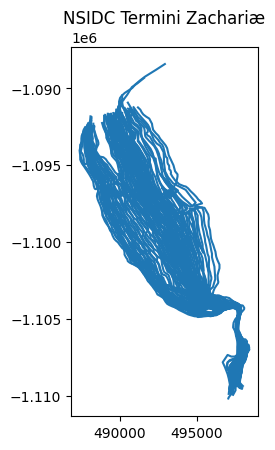

In [ ]:
zach_nsidc = nsidc[nsidc['Glacier_ID'] == 107]

# Add Month and Year columns to dataframe
zach_nsidc['Year'] = pd.to_datetime(zach_nsidc['SourceDate']).dt.year
zach_nsidc['Month'] = pd.to_datetime(zach_nsidc['SourceDate']).dt.month

zach_nsidc.plot()
plt.title("NSIDC Termini Zachariæ")
zach_nsidc

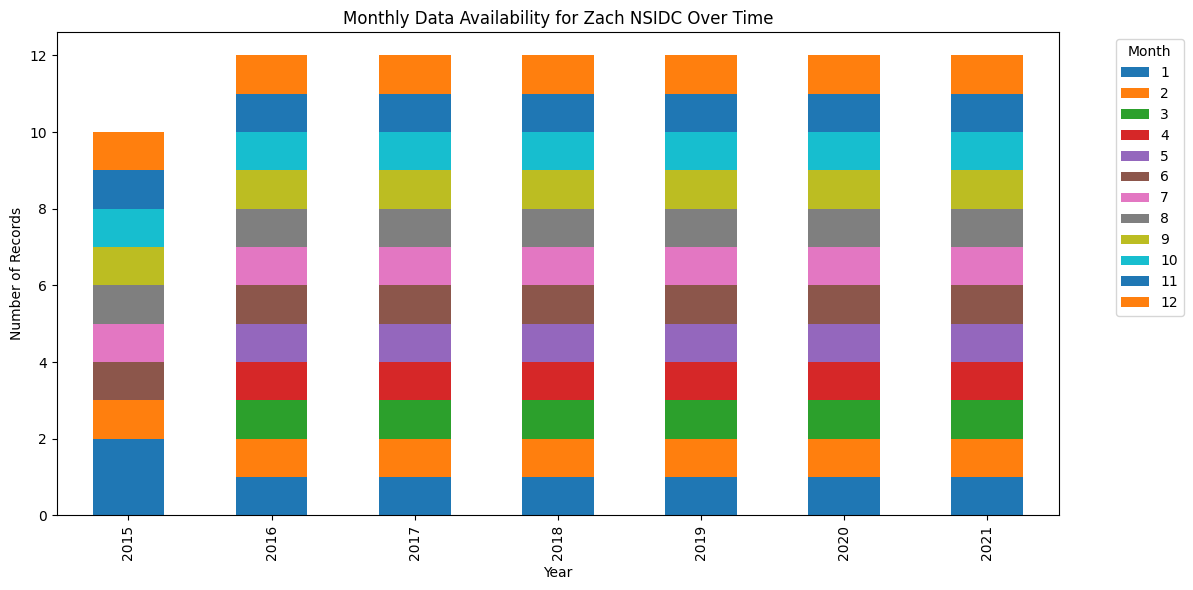

In [ ]:
monthly_counts = zach_nsidc.groupby(['Year', 'Month']).size().unstack()

monthly_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.title('Monthly Data Availability for Zach NSIDC Over Time')
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## AutoTerm

Termini are automatically digitized from Sentinel-2, Sentinel-1, and Landsat-8 imagery using a deep learning algorithm

,Date,Glacier ID,Satellite,Error,geometry,Year,Month
0,2013-03-26,GID102,Landsat8,223.5444223,"LINESTRING Z (-20.52522 78.98854 0, -20.52574 ...",2013,3
1,2013-04-01,GID102,Landsat8,223.5444223,"LINESTRING Z (-20.52348 78.9885 0, -20.524 78....",2013,4
2,2013-04-03,GID102,Landsat8,223.5444223,"LINESTRING Z (-20.52487 78.98569 0, -20.52539 ...",2013,4
3,2013-04-27,GID102,Landsat8,223.5444223,"LINESTRING Z (-20.52591 78.9879 0, -20.5273 78...",2013,4
4,2013-04-29,GID102,Landsat8,223.5444223,"LINESTRING Z (-20.52522 78.98877 0, -20.52591 ...",2013,4
...,...,...,...,...,...,...,...
909,2021-05-18,GID102,Sentinel2,194.26530465000002,"LINESTRING Z (-20.89197 79.00083 0, -20.8922 7...",2021,5
910,2021-05-19,GID102,Sentinel2,194.26530465000002,"LINESTRING Z (-20.89058 79.00083 0, -20.89082 ...",2021,5
911,2021-05-23,GID102,Sentinel2,194.26530465000002,"LINESTRING Z (-20.89105 79.00078 0, -20.89128 ...",2021,5
912,2021-05-24,GID102,Sentinel2,194.26530465000002,"LINESTRING Z (-20.89659 79.00078 0, -20.89705 ...",2021,5


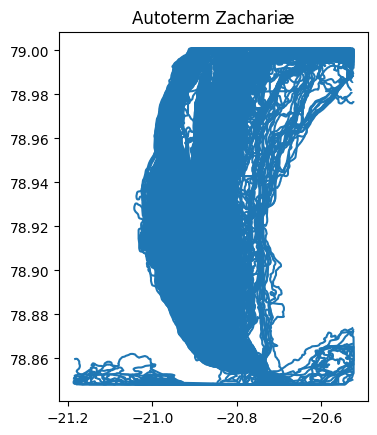

In [ ]:
# Add Month and Year columns to dataframe
zach_autoterm['Year'] = pd.to_datetime(zach_autoterm['Date']).dt.year
zach_autoterm['Month'] = pd.to_datetime(zach_autoterm['Date']).dt.month

zach_autoterm.plot()
plt.title("Autoterm Zachariæ")
zach_autoterm

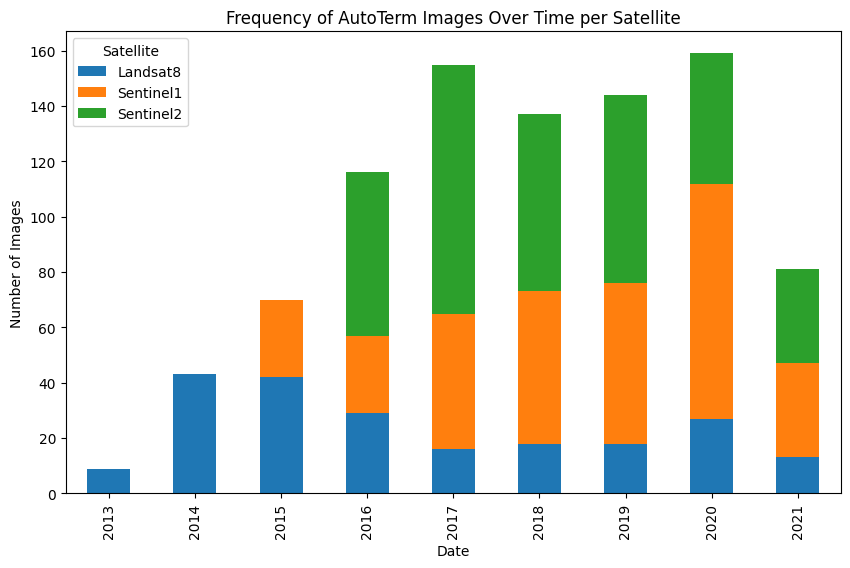

In [ ]:
zach_autoterm.groupby(['Year', 'Satellite']).size().unstack().plot(kind='bar', stacked=True, figsize=(10, 6))

plt.xlabel('Date')
plt.ylabel('Number of Images')
plt.title('Frequency of AutoTerm Images Over Time per Satellite')
plt.show()

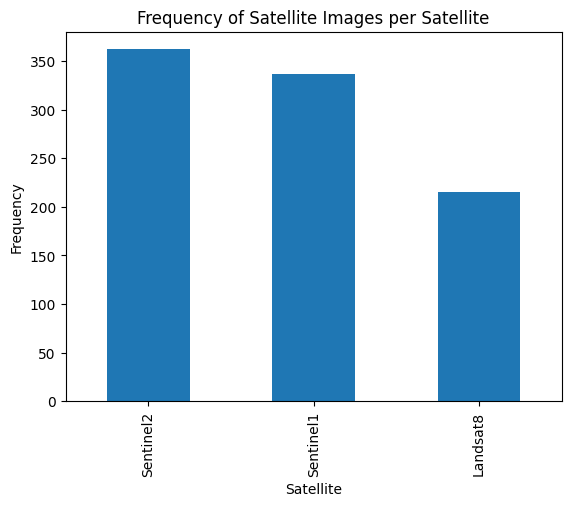

In [ ]:
zach_autoterm['Satellite'].value_counts().plot(kind='bar')
plt.xlabel('Satellite')
plt.ylabel('Frequency')
plt.title('Frequency of Satellite Images per Satellite')
plt.show()

## TermPicks

TermPicks data were compiled from a variety of satellites (mostly Landsat) over time.

/home/cjensen/miniconda3/envs/cjensetools/lib/python3.10/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,GlacierID,Date,Year,Month,Day,DecDate,QualFlag,Satellite,ImageID,Author,Center_X,Center_Y,geometry
15409,102,1990-09-23,1990.0,9.0,23,1990.726027,00,Landsat,LT50050031990266KIS00,ESA,-19.721503,78.943588,"MULTILINESTRING ((520707.541 -1075661.665, 520..."
15410,102,1994-09-16,1994.0,9.0,16,1994.706849,00,Landsat,LT50070031994259KIS00,ESA,-19.560593,78.939722,"MULTILINESTRING ((522160.677 -1107121.801, 522..."
15411,102,1995-10-03,1995.0,10.0,3,1995.753425,00,ERS1/ERS2/ENVISAT,SAR_IM__0PXESA19951003_140247_00000017A005_000...,ESA,-19.413917,78.977544,"MULTILINESTRING ((494358.929 -1114067.368, 494..."
15412,102,1998-09-13,1998.0,9.0,13,1998.698630,00,Landsat,LT50050031998256KIS00,ESA,-19.408642,78.964483,"MULTILINESTRING ((498266.482 -1106683.74, 4983..."
15413,102,1999-08-05,1999.0,8.0,5,1999.591781,00,Landsat,LE70070031999217KIS00,ESA,-19.552657,78.943366,"MULTILINESTRING ((494300.862 -1113857.382, 494..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15535,102,2015-07-24,2015.0,7.0,24,2015.558904,05,Landsat,LC08_L1TP_007003_20150724_20170406_01_T1,Wood,-20.713918,78.939585,"LINESTRING (497906 -1107200, 497906 -1107130, ..."
15536,102,1990-08-04,1990.0,8.0,4,1990.589041,05,Landsat,LT05_L1TP_007003_19900804_20170129_01_T1,Wood,-20.234102,78.721734,"LINESTRING (498152 -1106680, 498097 -1106500, ..."
15537,102,1989-09-02,1989.0,9.0,2,1989.668493,05,Landsat,LT05_L1TP_007003_19890902_20170201_01_T1,Wood,-20.246385,78.819232,"LINESTRING (499209 -1106340, 499267 -1106320, ..."
15538,102,1987-09-04,1987.0,9.0,4,1987.673973,05,Landsat,LT05_L1TP_008003_19870904_20170211_01_T1,Wood,-20.234730,78.819344,"LINESTRING (499137 -1106340, 499214 -1106320, ..."


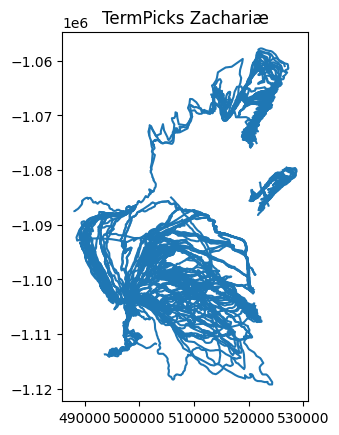

In [ ]:
zach_termpicks = termpicks[termpicks['GlacierID'] == 102]

zach_termpicks['Date'] = pd.to_datetime(zach_termpicks['Date'], errors='coerce')
zach_termpicks['Year'] = zach_termpicks['Date'].dt.year
zach_termpicks['Month'] = zach_termpicks['Date'].dt.month

zach_termpicks.plot()
plt.title("TermPicks Zachariæ")
zach_termpicks

### Sofia's Termini

In [ ]:
sofia_termini.sort_values('SourceDate')

,Glacier_ID,layer,Path,SourceDate,geometry
16,107,trace_06Jan22_17Jan22,/Users/sofiasuhinin/Desktop/GRIS/GRIMP IMAGERY...,2022-01-06,"LINESTRING (497603.307 -1104310.225, 497312.26..."
17,107,trace_06Jan22_17Jan22,/Users/sofiasuhinin/Desktop/GRIS/GRIMP IMAGERY...,2022-01-06,None
38,107,trace_11Feb22_22Feb22,/Users/sofiasuhinin/Desktop/GRIS/GRIMP IMAGERY...,2022-02-11,"LINESTRING (497747.75 -1104377.905, 497456.708..."
23,107,trace_07Mar22_18Mar22,/Users/sofiasuhinin/Desktop/GRIS/GRIMP IMAGERY...,2022-03-07,"LINESTRING (497721.292 -1104377.905, 497483.16..."
40,107,trace_12Apr22_23Apr22,/Users/sofiasuhinin/Desktop/GRIS/GRIMP IMAGERY...,2022-04-12,"LINESTRING (497641.917 -1104377.905, 497456.70..."
21,107,trace_06May22_17May22,/Users/sofiasuhinin/Desktop/GRIS/GRIMP IMAGERY...,2022-05-06,"LINESTRING (497684.191 -1104249.701, 497328.63..."
39,107,trace_11Jun22_22Jun22,/Users/sofiasuhinin/Desktop/GRIS/GRIMP IMAGERY...,2022-06-11,"LINESTRING (497573.311 -1104453.766, 497255.81..."
14,107,trace_05Jul22_16Jul22,/Users/sofiasuhinin/Desktop/GRIS/GRIMP IMAGERY...,2022-07-05,"LINESTRING (497599.769 -1104427.307, 497282.26..."
33,107,trace_10Aug22_21Aug22,/Users/sofiasuhinin/Desktop/GRIS/GRIMP IMAGERY...,2022-08-10,"LINESTRING (497679.144 -1104453.766, 497388.10..."
7,107,trace_03Sep22_14Sep22,/Users/sofiasuhinin/Desktop/GRIS/GRIMP IMAGERY...,2022-09-03,"LINESTRING (498975.603 -1104771.266, 498525.81..."


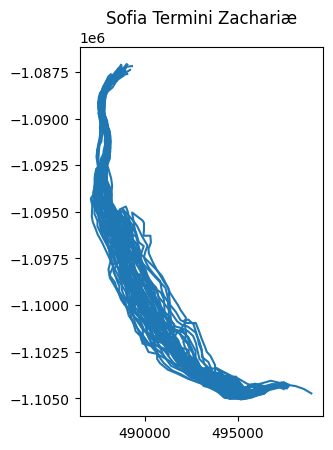

In [ ]:
sofia_termini.dropna()
sofia_termini['Year'] = pd.to_datetime(sofia_termini['SourceDate']).dt.year
sofia_termini['Month'] = pd.to_datetime(sofia_termini['SourceDate']).dt.month

sofia_termini.plot()
plt.title('Sofia Termini Zachariæ')
plt.show()

### Jensen Termini

In [10]:
jensen_termini.sort_values('Date')

,id,Date,ImagePath,SLCFlag,Satellite,Time,cloudShado,notes,otherImage,partialPic,...,Center_X,Center_Y,Glacier__1,Path_1,SourceDa_1,Date_jense,Satellite_,layer_jens,path_1_1,geometry
727,None,2000/07/04 00:00:00,None,NaN,Landsat,None,NaN,None,NaN,NaN,...,-20.190961,78.787668,NaN,None,None,None,None,None,None,"LINESTRING (521220.24 -1104974.708, 521017.254..."
560,None,2000/07/04 00:00:00,None,NaN,Landsat,None,NaN,None,NaN,NaN,...,-20.212838,78.832253,NaN,None,None,None,None,None,None,"LINESTRING (521959 -1106691, 521959 -1106736, ..."
746,None,2000/07/24 00:00:00,None,NaN,Landsat,None,NaN,None,NaN,NaN,...,-19.485947,78.945702,NaN,None,None,None,None,None,None,"MULTILINESTRING ((499680.365 -1110771.661, 499..."
501,1_1_1_1_1_1_1_1_1_2_0_0,2000/07/24 00:00:00,LANDSAT/LE07/C02/T1_RT_TOA/LE07_005003_20000724,0.0,LANDSAT_7,14:23:57.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,None,None,None,None,None,None,"MULTILINESTRING ((521731.946 -1088291.374, 521..."
0,2_0_0,2001/06/23 00:00:00,LANDSAT/LE07/C02/T1_RT_TOA/LE07_007003_20010623,0.0,LANDSAT_7,14:34:29.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,None,None,None,None,None,None,"LINESTRING (497753.666 -1107567.349, 498076.27..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,1_1_1_1_2_0_0,2026/03/14 00:00:00,COPERNICUS/S2/20260314T143919_20260314T143919_...,0.0,None,14:40:00.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,None,None,2026/03/14 00:00:00.000,SENTINEL_2,2025_01_01_2026_05_06_ZI_traces_2,/Users/cjense/Downloads/2025_01_01_2026_05_06_...,"LINESTRING (497641.069 -1104537.64, 497437.786..."
592,1_1_1_2_0_0,2026/03/31 00:00:00,LANDSAT/LC09/C02/T1_TOA/LC09_008003_20260331,0.0,None,14:51:09.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,None,None,2026/03/31 00:00:00.000,LANDSAT_9,2025_01_01_2026_05_06_ZI_traces_2,/Users/cjense/Downloads/2025_01_01_2026_05_06_...,"LINESTRING (497714.129 -1104653.317, 497563.76..."
599,1_1_2_0_0,2026/04/03 00:00:00,LANDSAT/LC08/C02/T1_RT_TOA/LC08_005004_20260403,0.0,None,14:32:41.000,0.0,None,1.0,0.0,...,NaN,NaN,NaN,None,None,2026/04/03 00:00:00.000,LANDSAT_8,2025_01_01_2026_05_06_ZI_traces_2,/Users/cjense/Downloads/2025_01_01_2026_05_06_...,"LINESTRING (497707.931 -1104621.496, 497548.97..."
590,1_2_0_0,2026/04/26 00:00:00,LANDSAT/LC09/C02/T1_TOA/LC09_046241_20260426,0.0,None,20:20:44.000,0.0,None,0.0,0.0,...,NaN,NaN,NaN,None,None,2026/04/26 00:00:00.000,LANDSAT_9,2025_01_01_2026_05_06_ZI_traces_2,/Users/cjense/Downloads/2025_01_01_2026_05_06_...,"LINESTRING (497717.461 -1104674.421, 497586.28..."


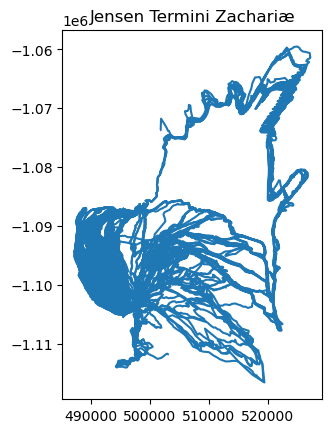

In [11]:
jensen_termini.dropna()
jensen_termini['Year'] = pd.to_datetime(jensen_termini['Date']).dt.year
jensen_termini['Month'] = pd.to_datetime(jensen_termini['Date']).dt.month

jensen_termini.plot()
plt.title('Jensen Termini Zachariæ')
plt.show()

## Compile and plot all data

In [12]:
# Group each dataset by Year and Month and count occurrences
# nsidc_counts = zach_nsidc.groupby(['Year', 'Month']).size().rename('NSIDC')
# # autoterm_counts = zach_autoterm.groupby(['Year', 'Month']).size().rename('AutoTerm')
# termpicks_counts = zach_termpicks.groupby(['Year', 'Month']).size().rename('TermPicks')
# sofia_counts = sofia_termini.groupby(['Year', 'Month']).size().rename('Sofia Termini')
jensen_counts = jensen_termini.groupby(['Year', 'Month']).size().rename('Jensen Termini')

# Create a complete index of all Year and Month combinations from 2000 to 2024
all_years_months = pd.MultiIndex.from_product(
    [range(2000, 2026), range(1, 13)], names=["Year", "Month"]
)

# Reindex each dataset to include all Year and Month combinations, filling missing values with 0
# nsidc_counts = nsidc_counts.reindex(all_years_months, fill_value=0)
# # autoterm_counts = autoterm_counts.reindex(all_years_months, fill_value=0)
# termpicks_counts = termpicks_counts.reindex(all_years_months, fill_value=0)
# sofia_counts = sofia_counts.reindex(all_years_months, fill_value=0)
jensen_counts = jensen_counts.reindex(all_years_months, fill_value=0)

# Combine all counts into a single DataFrame
# compiled_data = pd.concat([nsidc_counts, autoterm_counts, termpicks_counts, sofia_counts], axis=1).reset_index()
# compiled_data = pd.concat([nsidc_counts, termpicks_counts, sofia_counts, jensen_counts], axis=1).reset_index()
jensen_counts = pd.concat([jensen_counts], axis=1).reset_index()

# Fill NaN values with 0 (indicating no data for that dataset in a given month)
# compiled_data.fillna(0, inplace=True)
jensen_counts.fillna(0, inplace=True)

# Convert counts to integers
# compiled_data[['NSIDC', 'AutoTerm', 'TermPicks', 'Sofia Termini']] = compiled_data[['NSIDC', 'AutoTerm', 'TermPicks', 'Sofia Termini']].astype(int)
# compiled_data[['NSIDC', 'TermPicks', 'Sofia Termini', 'Jensen Termini']] = compiled_data[['NSIDC', 'TermPicks', 'Sofia Termini', 'Jensen Termini']].astype(int)
jensen_counts['Jensen Termini'] = jensen_counts['Jensen Termini'].astype(int)

# compiled_data.set_index(['Year', 'Month'], inplace=True)
jensen_counts.set_index(['Year', 'Month'], inplace=True)
jensen_counts
# compiled_data

Jensen Termini
Year Month                
2000 1                   0
     2                   0
     3                   0
     4                   0
     5                   0
...                    ...
2025 8                   2
     9                   3
     10                  0
     11                  0
     12                  0

[312 rows x 1 columns]

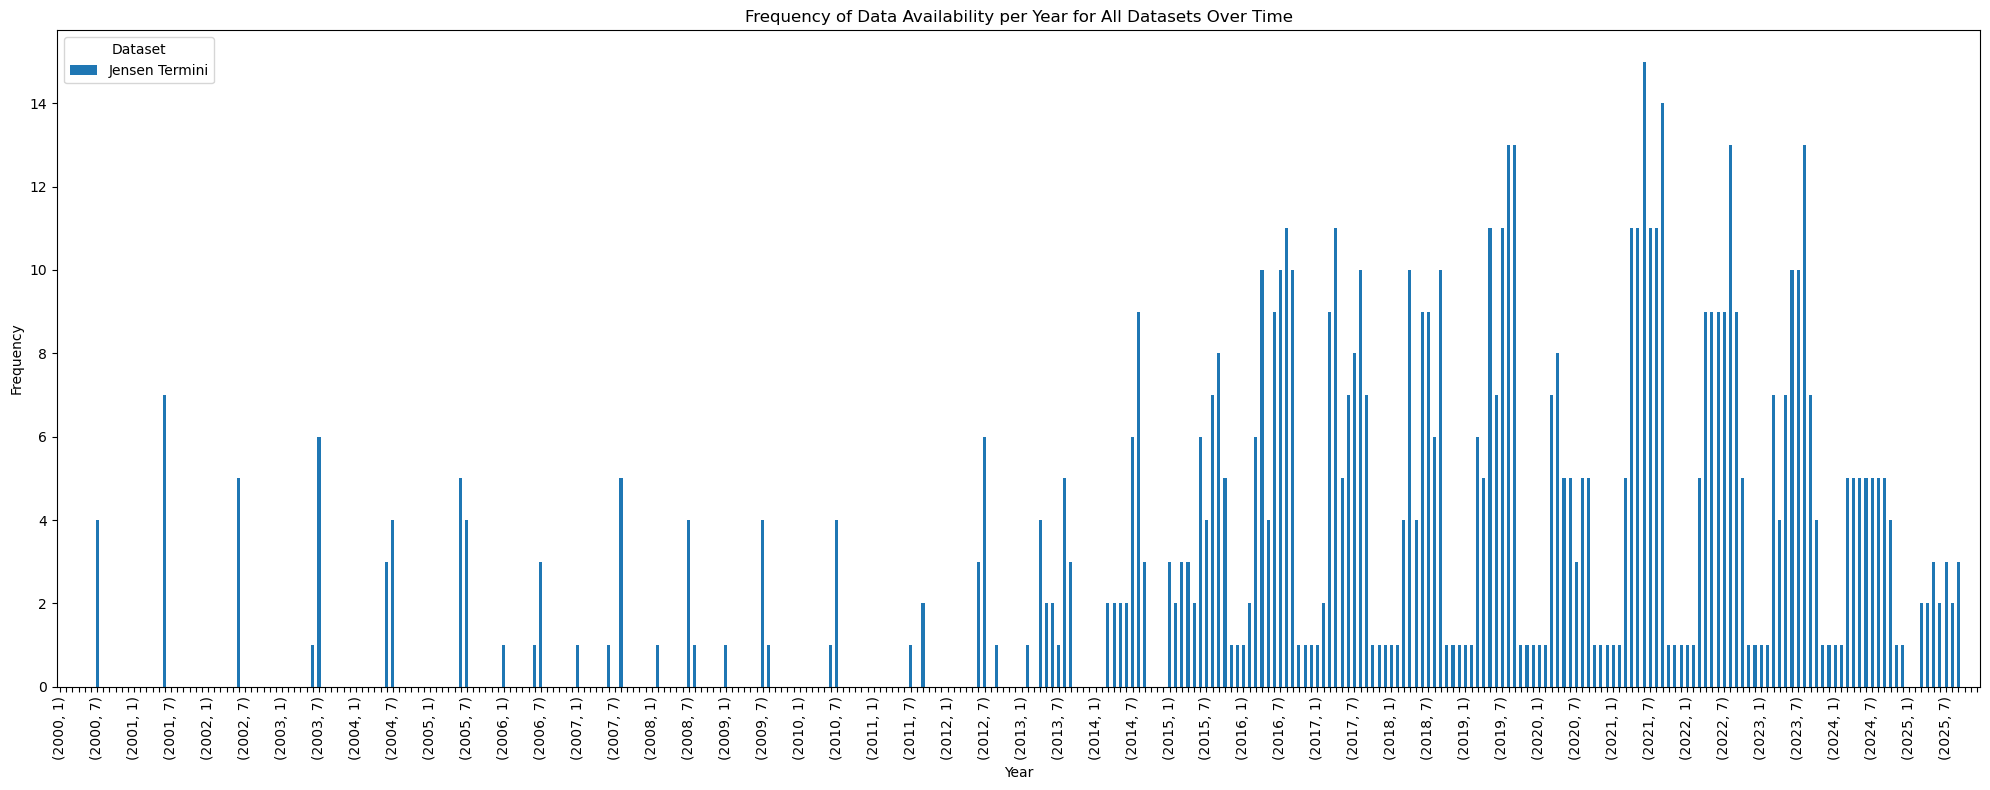

In [ ]:
# Convert to DataFrame
ax = jensen_counts.plot(kind='bar', stacked=True, figsize=(20, 8))

for i, t in enumerate(ax.get_xticklabels()):
    if (i % 6) != 0:
        t.set_visible(False)
        plt.xlabel('Year')
        
plt.ylabel('Frequency')
plt.title('Frequency of Data Availability per Year for All Datasets Over Time')
plt.legend(title='Dataset', loc='upper left')
plt.tight_layout()

# plt.savefig('zachariae_terminus_data_availability.png', dpi=300)
plt.show()

<Axes: >

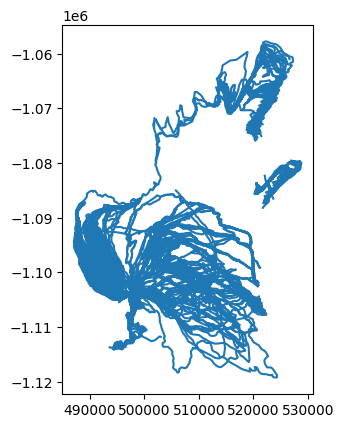

In [ ]:
compiled_data_plot = pd.merge(zach_nsidc, zach_termpicks, how='outer')
compiled_data_plot = pd.merge(compiled_data_plot, sofia_termini, how='outer')
compiled_data_plot = pd.merge(compiled_data_plot, jensen_termini, how='outer')

compiled_data_plot.plot()

In [ ]:
print(compiled_data.size)

1248


In [ ]:
compiled_data.to_csv('/home/cjensen/phd/Data/Termini/'+'all_termini_ZI.csv', index=False)